In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import torch

## preprocess and embedding

In [3]:
from src.preprocessing import pp
from sklearn.model_selection import train_test_split
import scvi

In [4]:
control_key = "is_control"
condition_keys = "target_gene"
condition_rep_keys = "gene_embeddings"

In [5]:
filePath = './data/raw/adata_Training.h5ad'
adata = sc.read_h5ad(filePath)
# adata = adata[adata.obs.sample(frac=1, random_state=42).index].copy()
print(adata)

AnnData object with n_obs × n_vars = 221273 × 18080
    obs: 'target_gene', 'guide_id', 'batch'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'ribo', 'n_cells'


In [6]:
adata.obs['is_control'] = (adata.obs['target_gene'] == "non-targeting")
gene_list = adata[adata.obs['is_control']==False].obs['target_gene'].unique()
print(adata.obs[control_key].value_counts())

is_control
False    183097
True      38176
Name: count, dtype: int64


In [7]:
rng = np.random.default_rng(42) 
test_ratio = 0.1
gene_list = list(gene_list)
print(gene_list)

# 分层抽样 先验证分布内学习能力
adata_pert = adata[adata.obs["is_control"] == False].copy()
y = adata_pert.obs["target_gene"].astype(str).values
idx = np.arange(adata_pert.n_obs)
train_idx, test_idx = train_test_split(
    idx,
    test_size=test_ratio,
    random_state=42,
    stratify=y 
)
adata_train = adata_pert[train_idx].copy()
adata_test = adata_pert[test_idx].copy()
adata_control = adata[adata.obs["is_control"] == True].copy()
del adata, adata_pert

# 按基因分割 zero-shot
# n_test = max(1, int(len(gene_list) * test_ratio))
# test_gene = rng.choice(gene_list, size=n_test, replace=False).tolist()
# train_gene = [g for g in gene_list if g not in test_gene]
# adata_control = adata[adata.obs['is_control']==True].copy() # control的target_gene是non-targeting
# adata_train = adata[adata.obs["target_gene"].isin(train_gene)].copy() 
# adata_test = adata[adata.obs["target_gene"].isin(test_gene)].copy()
# del adata

['CDCA2', 'DHX36', 'TMSB10', 'KAT2A', 'PHF14', 'KLF10', 'KDM1A', 'STAT1', 'ACAT2', 'STX4', 'HMGB2', 'TADA1', 'MTA1', 'C1QBP', 'SMARCA4', 'PTPN1', 'TGFBR2', 'IGF2R', 'USP22', 'MAST2', 'DHCR24', 'DAXX', 'KIF1B', 'BIRC2', 'CAST', 'NCK2', 'TET1', 'ZNF562', 'SRC', 'LAD1', 'POLB', 'TRAM2', 'MAP3K7', 'MED13', 'IDE', 'HIRA', 'CENPO', 'PRR12', 'MED12', 'DZIP3', 'UBE3C', 'CASP3', 'PRCP', 'CLDN7', 'MKI67', 'HAT1', 'PAGR1', 'RRM1', 'KDM2B', 'CAMSAP2', 'WFS1', 'NDUFB6', 'ZNF714', 'MAP1B', 'SSBP1', 'EIF4B', 'CLDN6', 'UQCRQ', 'HMGN1', 'KDR', 'ANTXR1', 'DNMT1', 'TARBP2', 'METTL17', 'GSK3B', 'ZNF593', 'METTL14', 'TWF2', 'RNF2', 'SMAGP', 'STAG2', 'IKBKG', 'RAB3B', 'ZNF286A', 'XRCC4', 'ATP1B1', 'LRPPRC', 'SEC62', 'CREG1', 'ETV4', 'ZNF426', 'SIX4', 'SMARCA5', 'FOXH1', 'NIT1', 'NISCH', 'AKT2', 'SALL4', 'OXA1L', 'EWSR1', 'LZTR1', 'SUPT4H1', 'MAPKAPK2', 'TSC22D4', 'MAU2', 'TMSB4X', 'ARID1A', 'STAT6', 'RAF1', 'CHMP3', 'KIF20A', 'IRF3', 'MED13L', 'PMS1', 'TAZ', 'EID2', 'SOX2', 'SHPRH', 'ATP6V0B', 'SIN3B', 'ACV

In [16]:
#sample_rep = "X_pca" 
sample_rep = "X_scVI"
n_comps = 100
condition_rep_dict = pd.read_pickle("./data/processed/vcc_data_target_genes_embedding.pkl")
model_ref = None
if sample_rep == "X_scVI":
    adata_control.layers["counts"] = adata_control.X.copy()
    adata_train.layers["counts"] = adata_train.X.copy()
    if adata_test is not None:
        adata_test.layers["counts"] = adata_test.X.copy()

    scvi_save_path = "./results/checkpoints/scvi"
    if True:
        try:
            model_ref = scvi.model.SCVI.load(f"{scvi_save_path}_ref", adata=adata_control)
        except (FileNotFoundError, OSError, ValueError) as e:
            model_ref = None 
        try:
            model_train = scvi.model.SCVI.load(f"{scvi_save_path}_train", adata=adata_train)
        except (FileNotFoundError, OSError, ValueError) as e:
            model_train = None
        if adata_test is not None:
            try:
                model_test = scvi.model.SCVI.load(f"{scvi_save_path}_test", adata=adata_test)
            except (FileNotFoundError, OSError, ValueError) as e:
                model_test = None


INFO     File ./results/checkpoints/scvi_ref/model.pt already downloaded                                           
INFO     No backup URL provided for missing file ./results/checkpoints/scvi_train/model.pt                         
INFO     No backup URL provided for missing file ./results/checkpoints/scvi_test/model.pt                          


In [18]:
adata_control, adata_train, adata_test, model_ref, model_train, model_test = pp.process_to_embedding( 
    adata_control,
    adata_train,
    adata_test = adata_test,
    sample_rep = sample_rep,
    n_comps = n_comps,
    model_ref = model_ref,
    model_train = model_train,
    model_test = model_test,
    scvi_save_path = scvi_save_path,
    condition_rep_dict = condition_rep_dict
    )
if sample_rep == "X_pca":
    sample_rep_scaled = sample_rep + "_scaled" # 额 别忘了
else:
    sample_rep_scaled = sample_rep

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


projecting


/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:534: Found 33 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Training:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:534: Found 33 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Training:   0%|          | 0/100 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x14f1df3f68c0>
Traceback (most recent call last):
  File "/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
  File "/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x14f1df3f68c0>
Traceback (most recent call last):
  File "/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/torch/utils/data/dataload

Control Std: [0.95657474 0.02180273 0.02279867 0.02426531 0.01806189 0.02012757
 0.02315027 1.0277311  0.02297903 0.02001494 0.02044014 0.02018435
 0.02215145 0.02209805 0.0185152  0.01847793 0.9447653  0.96942645
 0.8906287  1.0254579  0.9984138  0.9069665  0.02047578 0.02039085
 0.02045253 0.02672228 0.86808455 1.1027513  0.87464356 0.99061
 0.9535475  0.9679389  0.02321177 0.91959673 0.02504403 0.9160012
 0.02108885 1.2494253  0.89321816 0.0218688  0.0221687  0.9584846
 0.02217302 0.8978939  1.1473889  1.1298901  1.000616   0.948281
 0.8669067  0.02033016 0.0179049  0.9723324  1.1654682  0.8377735
 0.02183941 0.9349883  0.02136864 0.02491575 0.02313016 0.0246333
 0.0243912  0.89046794 0.02446375 0.02075002 0.02838927 0.02181062
 0.02266466 0.9618946  0.92153436 0.8767562  0.02390431 0.9359046
 0.8299141  0.88318014 0.02192813 0.96239656 1.0578439  0.01814377
 1.0250602  1.0337551  0.93858767 0.02154927 0.01978795 0.872001
 0.885608   0.932754   0.881881   0.0258278  0.91616046 0.938

## training

In [19]:
from src.training import pre_compute_wfr_ot
from src.training import FNet,train
from torch.optim.lr_scheduler import CosineAnnealingLR

In [20]:
delta = 10
reg_m = 1
use_mini_batch_uot = False # mini_batch逻辑暂时还没有写
group_number = 3
save_path_train = f"./data/processed/vcc_ot_precompute_delta{delta}_reg_m{reg_m}_{sample_rep_scaled}_train.pkl"
save_path_test = f"./data/processed/vcc_ot_precompute_delta{delta}_reg_m{reg_m}_{sample_rep_scaled}_test.pkl"


# 记得修改抽样方法后重新计算
load_saved = True
if os.path.exists(save_path_train) and load_saved:
    ot_results_train = pd.read_pickle(save_path_train)
else:
    ot_results_train = pre_compute_wfr_ot(adata_control, 
                           adata_train, 
                           save_path_train, 
                           sample_rep=sample_rep_scaled, 
                           condition_keys=condition_keys,
                           delta = delta,
                           reg_m = reg_m,
                           group_number = group_number,
                           use_mini_batch_uot = use_mini_batch_uot,
                            draw = False)

if os.path.exists(save_path_test) and load_saved:
    ot_results_test = pd.read_pickle(save_path_test)
else:
    ot_results_test = pre_compute_wfr_ot(adata_control, 
                           adata_test, 
                           save_path_test, 
                           sample_rep=sample_rep_scaled, 
                           condition_keys=condition_keys,
                           delta = delta,
                           reg_m = reg_m,
                           group_number = group_number,
                           use_mini_batch_uot = use_mini_batch_uot,
                            draw=False)


In [21]:
# save_path = "./results/vcc/vcc_dvc_model.pt"
save_path = "./results/checkpoints/vcc_dvc"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
n_iterations = 30000

# 模型参数没有仔细调 
in_out_dim = adata_control.obsm[sample_rep_scaled].shape[1]
hidden_dim_v = 4096 # dynamic network
hidden_dim_g = 2048 
n_hiddens_v = 4
n_hiddens_g = 2
condition_dim = adata_train.obsm[condition_rep_keys].shape[1]
con_embedding_dim = 512  # condition encode dim
hidden_dim_con = 1024 # condition network
time_dim = 1024 # time embedding
time_embedding_dim = 256
hidden_dim_time = 512
bottle_dim = 1024
activation = 'GELU'

model = FNet(in_out_dim, hidden_dim_v, n_hiddens_v, hidden_dim_g, n_hiddens_g, 
                 condition_dim, con_embedding_dim, hidden_dim_con, 
                 time_dim ,time_embedding_dim,hidden_dim_time, 
                 bottle_dim, activation)


load_model = False
if load_model:
    load_path = "./results/checkpoints/vcc_dvc_epoch_30000.pt"
    checkpoint = torch.load(load_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device) 
    model.eval() 
    print("load saved_model")

cuda


In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = None
scheduler = CosineAnnealingLR(optimizer, T_max=n_iterations, eta_min=5e-6)
train.train_model(adata_control, adata_train, adata_test,
                ot_results_train, ot_results_test, 
                model.to(device),
                optimizer,
                scheduler = scheduler,
                n_iterations= n_iterations,
                batch_size_per_condition = 256,
                batch_size_condition = 10,
                sample_rep = sample_rep_scaled,
                condition_keys=condition_keys,
                condition_rep_keys = condition_rep_keys,
                device = device,
                save_path=save_path,
                eval_interval = 10)


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/training/data.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.treated_indices_map = adata_treated.obs.groupby(condition_keys).indices
/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/training/data.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self.treated_indices_map = adata_treated.obs.groupby(condition_keys).indices


data_loaded
data_loaded


Begin flow and growth matching...:   0%|          | 83/30000 [00:26<2:24:31,  3.45epoch/s, loss=0.182, vloss=0.081, gloss=0.101]                 

训练步数: 9900
最后一步 Loss: 0.033164
最后一步 vLoss: 0.032544
最后一步 gLoss: 0.000620
最后一步 test_Loss: 0.232927


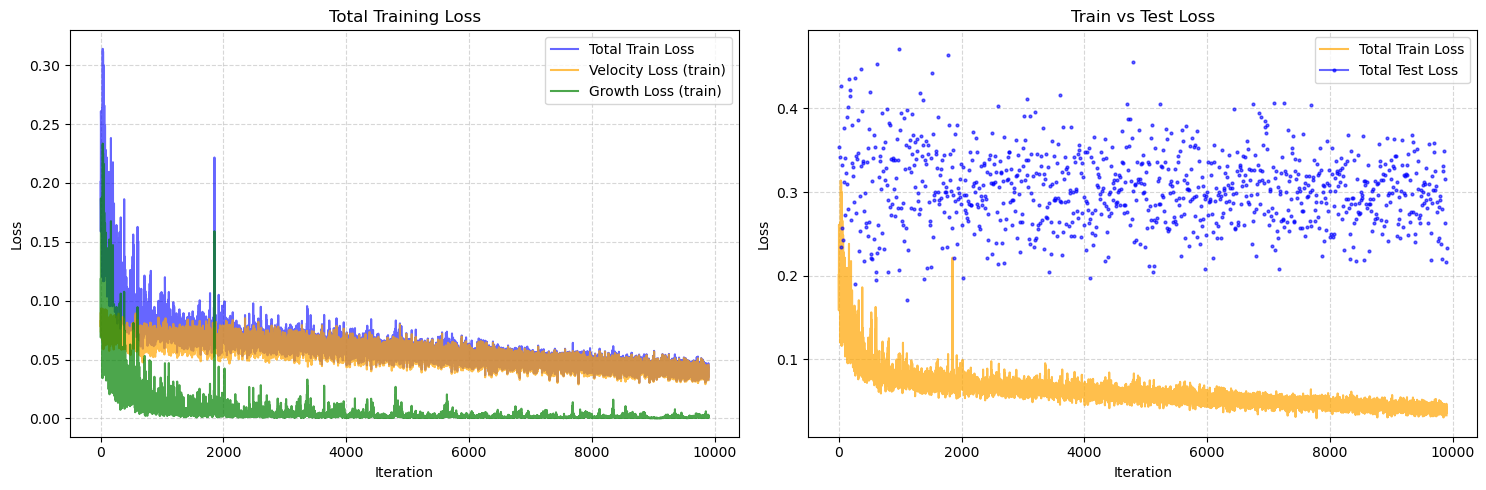

In [15]:
from src.evaluate import draw_loss
load_path = "./results/checkpoints/vcc_dvc_epoch_10000.pt"
draw_loss(load_path,eval_interval = 10,cut = 100)

## inference & evalutaion

In [20]:
from src.evaluate import run_batch_inference
# target_genes = ['CDCA2', 'DHX36', 'TMSB10', 'KAT2A', 'PHF14', 'KLF10', 'KDM1A', 'STAT1', 'ACAT2', 'STX4', 'HMGB2', 'TADA1', 'MTA1', 'C1QBP']
target_genes = ['CDCA2', 'DHX36', 'TMSB10']
                
n_particles = 5000
all_indices = np.arange(adata_control.n_obs)
rng = np.random.default_rng(42)
indices = rng.choice(all_indices, n_particles, replace=False) if n_particles < len(all_indices) else all_indices
adata_source = torch.tensor(adata_control.obsm[sample_rep_scaled][indices], dtype=torch.float32, device=device)

results_embedding = run_batch_inference(
    model=model,
    adata_source=adata_source,
    adata_conditions=adata_train,
    target_conditions=target_genes,
    condition_keys = condition_keys,
    embedding_key = condition_rep_keys,
    source_rep = sample_rep_scaled,
    n_steps = 50, # ode step
    device = device,
    random_seed = 42
)

  0%|          | 0/3 [00:00<?, ?it/s]/home/nepenthes/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
 33%|███▎      | 1/3 [00:00<00:00,  3.88it/s]/home/nepenthes/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
 67%|██████▋   | 2/3 [00:00<00:00,  4.30it/s]/home/nepenthes/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
100%|██████████| 3/3 [00:00<00:00,  4.48it/s]


In [ ]:
from src.evaluate import batch_reconstruct_pca, batch_reconstruct_scvi

# 我们可以reconstruct出原始基因表达
# 这里 m应该咋用呢
if sample_rep == "X_pca":
    results_genes = batch_reconstruct(
        inference_results=results_embedding,  
        ref_adata=adata_control        
    )
elif sample_rep == "X_scVI":
    results_genes = batch_reconstruct_scvi(
        inference_results=results_embedding,
        scvi_model=model_ref,  # 传入模型
        target_library_size=1e4 # 输出将被标准化到 10,000 counts
    )



In [21]:
#print(results_embedding)
print(results_genes)

{'CDCA2': AnnData object with n_obs × n_vars = 3656 × 18080
    obs: 'condition', 'mass'
    uns: 'reconstruction_params', 'DHX36': AnnData object with n_obs × n_vars = 3656 × 18080
    obs: 'condition', 'mass'
    uns: 'reconstruction_params', 'TMSB10': AnnData object with n_obs × n_vars = 3656 × 18080
    obs: 'condition', 'mass'
    uns: 'reconstruction_params'}


In [ ]:
ground_truth_df = model_ref.get_normalized_expression(
    adata_train, 
    library_size=1e4,
    return_numpy=True
)

Plotting CDCA2...


/home/nepenthes/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


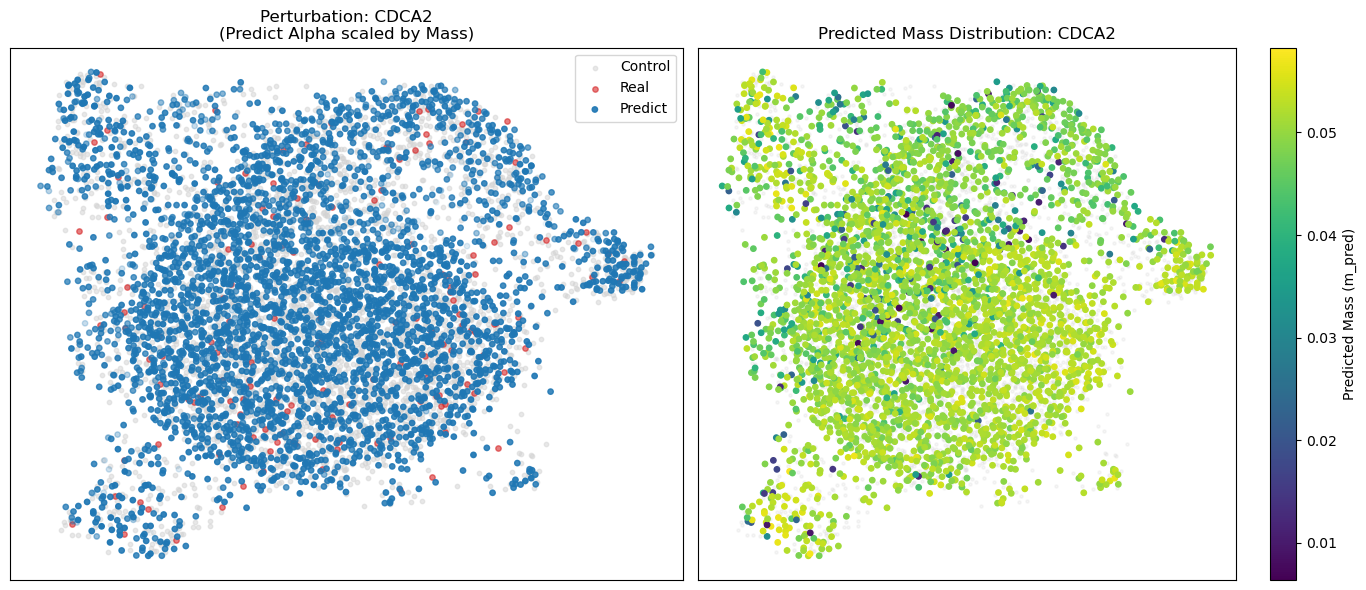

Plotting DHX36...


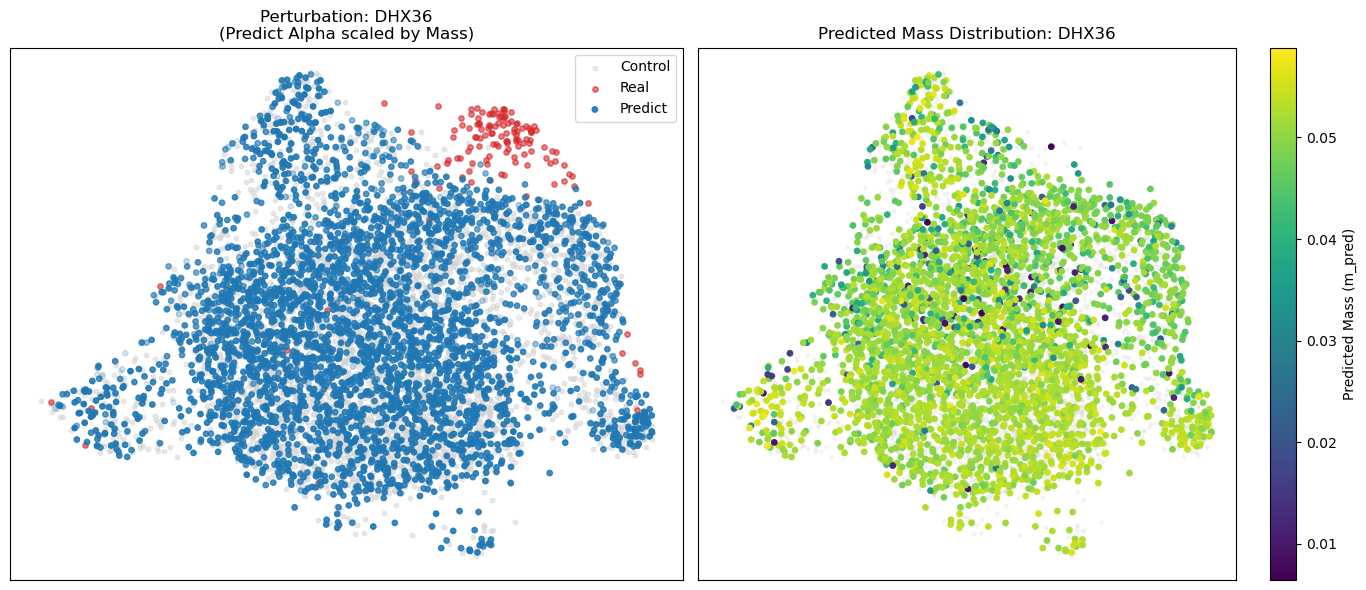

Plotting TMSB10...


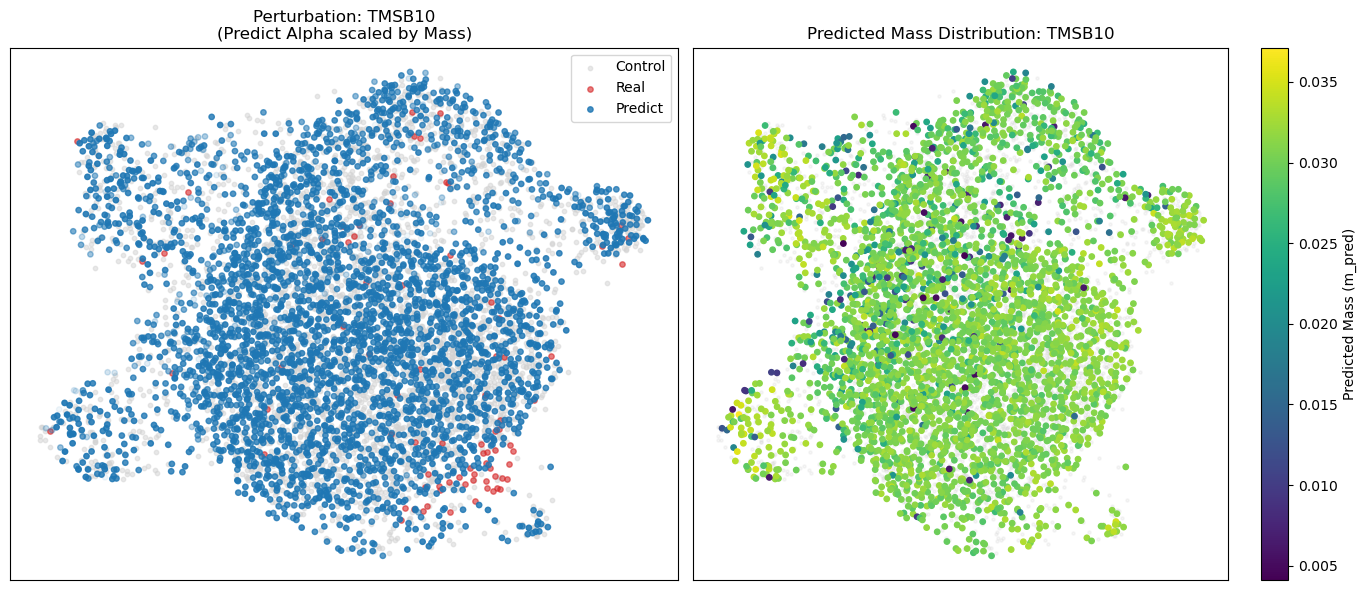

In [22]:
from src.evaluate import plot_perturbation_umap
plot_perturbation_umap(
    results_embedding=results_embedding,
    adata_control=adata_control,
    adata_conditions=adata_train, # 或者 adata_test
    target_genes=target_genes,
    control_indices=indices, 
    rep_key=sample_rep_scaled
)

Plotting CDCA2...


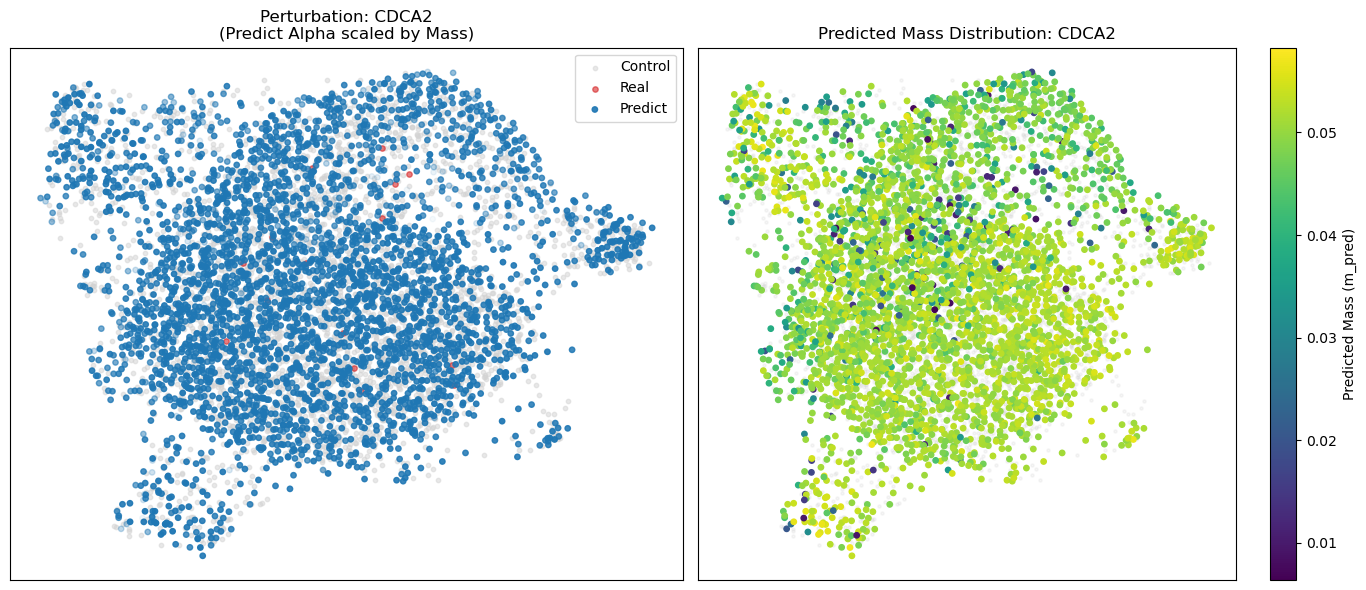

Plotting DHX36...


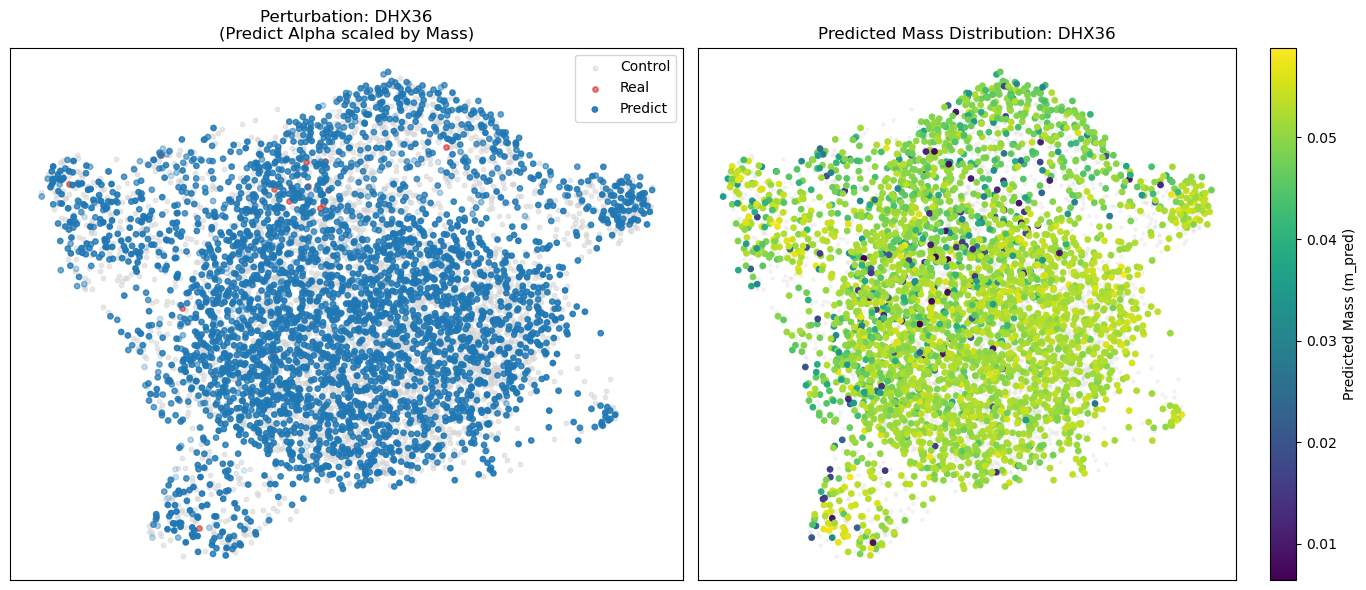

Plotting TMSB10...


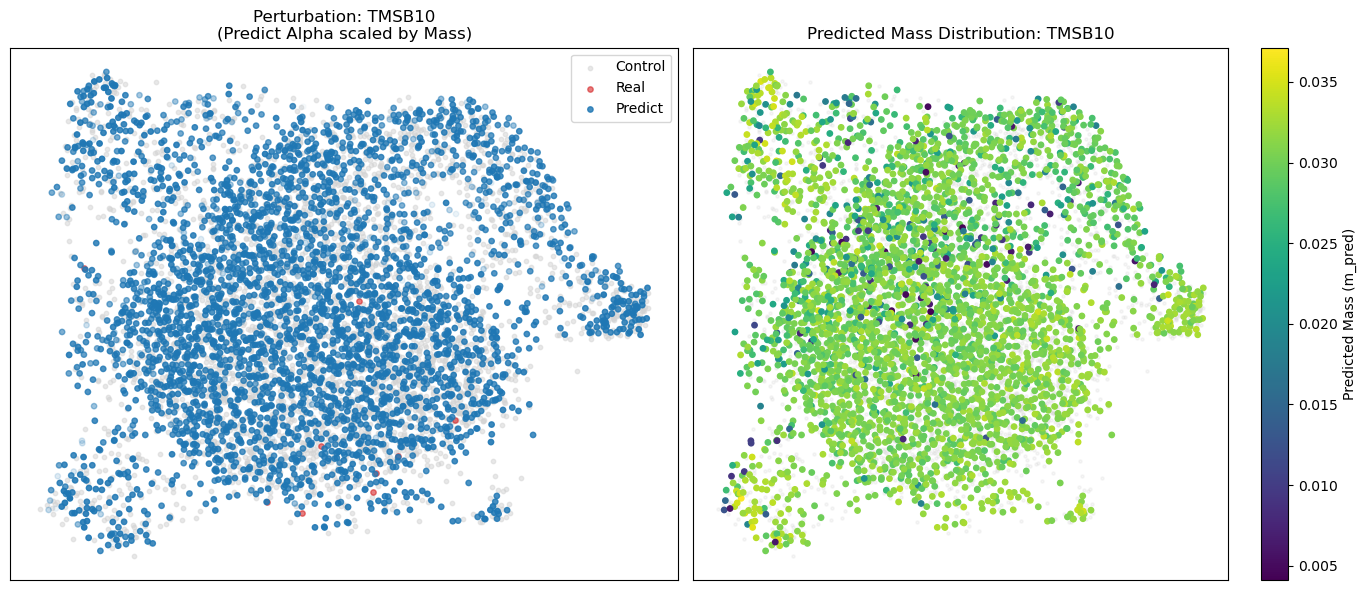

In [23]:
plot_perturbation_umap(
    results_embedding=results_embedding,
    adata_control=adata_control,
    adata_conditions=adata_test, # 或者 adata_test
    target_genes=target_genes,
    control_indices=indices, 
    rep_key=sample_rep_scaled
)

In [24]:
for target in target_genes: # ['CDCA2', 'DHX36', 'TMSB10']
    plot_top_degs_violin(
        reconstructed_data=results_genes,
        adata_control=adata_control,
        adata_real=adata_train,
        target_gene=target,
        top_n=4 # 展示 Target + Top 4 下游基因
    )

NameError: name 'plot_top_degs_violin' is not defined

In [ ]:
for target in target_genes: # ['CDCA2', 'DHX36', 'TMSB10']
    plot_top_degs_violin(
        reconstructed_data=results_genes,
        adata_control=adata_control,
        adata_real=adata_test,
        target_gene=target,
        top_n=4 # 展示 Target + Top 4 下游基因
    )

=== Mass Statistics for CDCA2 prediction ===
Mean Mass: 0.0402
Max  Mass: 0.0529
Min  Mass: 0.0137
Std  Mass: 0.0019


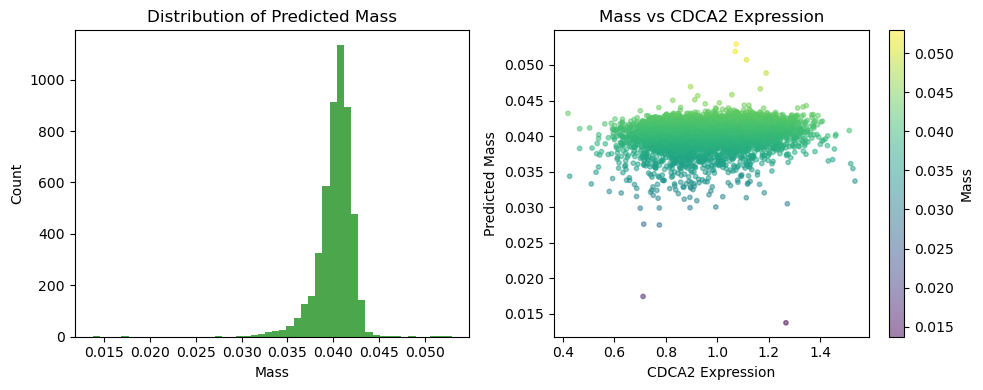

=== Mass Statistics for DHX36 prediction ===
Mean Mass: 0.0320
Max  Mass: 0.0591
Min  Mass: 0.0151
Std  Mass: 0.0032


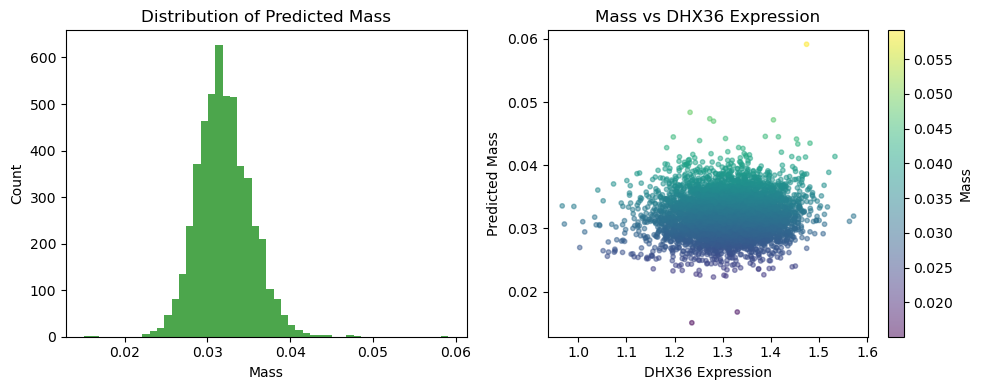

=== Mass Statistics for TMSB10 prediction ===
Mean Mass: 0.0209
Max  Mass: 0.0300
Min  Mass: 0.0084
Std  Mass: 0.0014


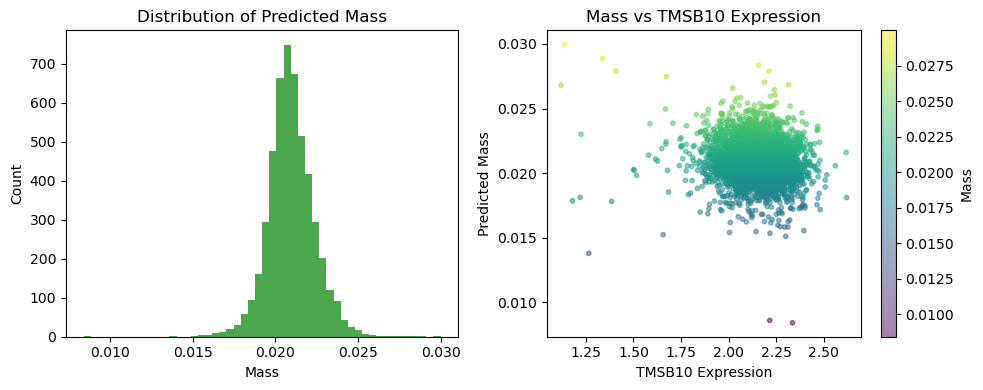

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def diagnose_mass_prediction(pred_adata, gene_name='CDCA2'):
    mass = pred_adata.obs['mass'].values
    expr = pred_adata[:, gene_name].X.flatten() # 或者是 .layers['counts'] 等
    
    # 1. 打印统计数据
    print(f"=== Mass Statistics for {gene_name} prediction ===")
    print(f"Mean Mass: {np.mean(mass):.4f}")
    print(f"Max  Mass: {np.max(mass):.4f}")
    print(f"Min  Mass: {np.min(mass):.4f}")
    print(f"Std  Mass: {np.std(mass):.4f}")
    
    # 2. 绘图：Mass vs Target Gene Expression
    plt.figure(figsize=(10, 4))
    
    # 子图1: Mass 的直方图
    plt.subplot(1, 2, 1)
    plt.hist(mass, bins=50, color='green', alpha=0.7)
    plt.title("Distribution of Predicted Mass")
    plt.xlabel("Mass")
    plt.ylabel("Count")
    
    # 子图2: Mass vs Expression
    plt.subplot(1, 2, 2)
    plt.scatter(expr, mass, alpha=0.5, s=10, c=mass, cmap='viridis')
    plt.title(f"Mass vs {gene_name} Expression")
    plt.xlabel(f"{gene_name} Expression")
    plt.ylabel("Predicted Mass")
    plt.colorbar(label='Mass')
    
    plt.tight_layout()
    plt.show()

# 运行诊断
for gene in target_genes:
    diagnose_mass_prediction(results_genes[gene], gene)